<a href="https://colab.research.google.com/github/ravali217/nlp/blob/main/nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import re
dataset=[]
text=[
    "I love coding!",
    "I love python#$",
    "python coding is fun"

]
for sentence in text:
  sentence=sentence.lower()
  sentence=re.sub(r'\W',' ',sentence)
  sentence=re.sub(r'\s',' ',sentence)
  dataset.append(sentence)
print(dataset)

['i love coding ', 'i love python  ', 'python coding is fun']


In [5]:
# step 2 counting word frequencies
# count how many times each word appears
from collections import defaultdict
word2count=defaultdict(int)
for sentence in dataset:
  for word in sentence.split():
    word2count[word]+=1
print(word2count)

defaultdict(<class 'int'>, {'i': 2, 'love': 2, 'coding': 2, 'python': 2, 'is': 1, 'fun': 1})


In [6]:
# selecting most frequent words
# let's take top 3 words
import heapq
freq_words=heapq.nlargest(3,word2count,key=word2count.get)
print(freq_words)

['i', 'love', 'coding']


In [13]:
# step 4 build bag of words matrix
# now we create a matrix:
# rows=sentences
# columns=frequent words
# value =1(present) or 0 (absent)
x=[]
for sentence in dataset:
  vector=[]
  words=sentence.split()
  for word in freq_words:
    if word in words:
      vector.append(1)
    else:
      vector.append(0)
  x.append(vector)
print(x)

[[1, 1, 1], [1, 1, 0], [0, 0, 1]]


In [16]:
# n- grams
# n-grams capture word sequences
# n-gram is a technique that splits text into sequences of n consecutive words
# step 1: preprocessing the text
import re
text=[
    "I love coding",
    "I love python",
    "python coding is fun"

]
dataset=[]
for sentence in text:
  sentence=sentence.lower()
  sentence=re.sub(r'\W',' ',sentence)
  sentence=re.sub(r'\s+',' ',sentence)
  dataset.append(sentence)
print(dataset)

['i love coding', 'i love python', 'python coding is fun']


In [17]:
# step 2: create n-grams
#function to generate n-grams
def generate_ngrams(sentence,n):
  words=sentence.split()
  ngrams=[]
  for i in range(len(words)-n+1):
    ngrams.append(" ".join(words[i:i+n]))
  return ngrams

In [18]:
#example: Bigrams(N=2)
for sentence in dataset:
  bigrams=generate_ngrams(sentence,2)
  print(bigrams)
for sentence in dataset:
  bigrams=generate_ngrams(sentence,2)
  print(bigrams)

['i love', 'love coding']
['i love', 'love python']
['python coding', 'coding is', 'is fun']
['i love', 'love coding']
['i love', 'love python']
['python coding', 'coding is', 'is fun']


In [19]:
#step3 count N-gram frequencies
from collections import defaultdict
ngram2count=defaultdict(int)
for snetence in dataset:
  ngram=generate_ngrams(sentence,2)
  for gram in ngram:
    ngram2count[gram]+=1
print(ngram2count)

defaultdict(<class 'int'>, {'python coding': 3, 'coding is': 3, 'is fun': 3})


In [22]:
# step4: convert into feature vector (like bow):
#select top N-Grams:
import heapq
freq_ngrams=heapq.nlargest(3,ngram2count,key=ngram2count.get)
print(freq_ngrams)


['python coding', 'coding is', 'is fun']


In [23]:
x=[]
for sentence in dataset:
  vector=[]
  sentence_ngrams=generate_ngrams(sentence,2)
  for gram in freq_ngrams:
    if gram in sentence_ngrams:
      vector.append(1)
    else:
      vector.append(0)
  x.append(vector)
print(x)

[[0, 0, 0], [0, 0, 0], [1, 1, 1]]


In [24]:
text=[
    "I love coding",
    "I love python",
    "python is powerful"

]
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer()
# initializes the TF-IDF model
#Tokenize text
#remove stopwords(optional)
#compute TF-IDF
x=vectorizer.fit_transform(text)
print(vectorizer.get_feature_names_out())
print(x.toarray())

['coding' 'is' 'love' 'powerful' 'python']
[[0.79596054 0.         0.60534851 0.         0.        ]
 [0.         0.         0.70710678 0.         0.70710678]
 [0.         0.62276601 0.         0.62276601 0.4736296 ]]


In [25]:
# word embedding
# they capture meaning and
#1. word2vec
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.3 MB/s eta 0:00:00


In [27]:
#CBOW
from gensim.models import Word2Vec
sentences=[
    ["i","love","coding"],
    ["i","love","python"],
    ["python","is","powerful"]
]
#train CBOW model(sg=0)
cbow_model=Word2Vec(sentences,
                    min_count=1,
                    vector_size=5,
                    window=2,
                    sg=0)
#Get word vector
print("vector for coding:")
print(cbow_model.wv["coding"])
#find similar words
print("similar to coding:")
print(cbow_model.wv.most_similar("coding"))



vector for coding:
[-0.06810732 -0.01892803  0.11537147 -0.15043275 -0.07872207]
similar to coding:
[('love', 0.774187445640564), ('powerful', 0.766875147819519), ('python', -0.0006994431605562568), ('is', -0.15349125862121582), ('i', -0.6143277883529663)]


In [29]:
!pip install nltk

In [43]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package w

True

In [44]:

sentence="Elon Musk visited India"
words=nltk.word_tokenize(sentence)
pos_tags=nltk.pos_tag(words)
ner_tree=nltk.ne_chunk(pos_tags)
print(ner_tree)

(S (PERSON Elon/NNP) (PERSON Musk/NNP) visited/VBD (GPE India/NNP))


In [45]:
!pip install spacy
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 95.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [46]:
import spacy
nlp=spacy.load("en_core_web_sm")
doc=nlp("Elon Musk founded Tesla in California")
for ent in doc.ents:
  print(ent.text,"+",ent.label_)

Elon Musk + PERSON
Tesla + ORG
California + GPE


In [61]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

path = '/content/drive/My Drive/spam.csv'

# ✅ FIX HERE
df = pd.read_csv(path, encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [59]:
df.shape

(5572, 5)

In [60]:
df.count()

,0
v1,5572
v2,5572
Unnamed: 2,50
Unnamed: 3,12
Unnamed: 4,6


In [64]:
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [67]:
df['length']=df['message'].apply(len)
print("average length of message:")
print(df['length'].mean())

average length of message:
80.11880832735105


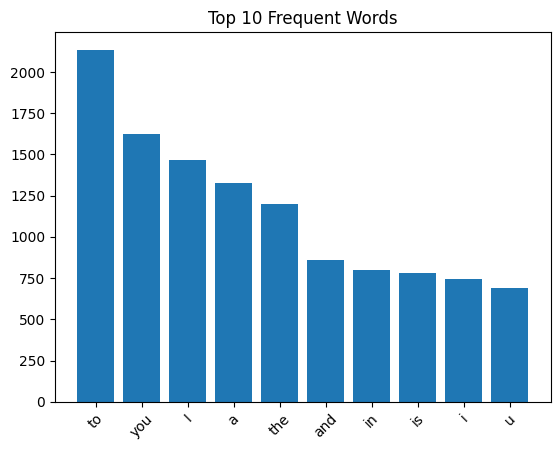

In [68]:
import matplotlib.pyplot as plt
from collections import Counter

all_words = " ".join(df['message']).split()
word_counts = Counter(all_words)

common_words = word_counts.most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Frequent Words")
plt.show()

In [69]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [70]:
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Lowercase
    text = text.lower()

    # Tokenize
    words = word_tokenize(text)

    # Remove punctuation & stopwords
    words = [w for w in words if w.isalnum() and w not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

In [71]:
df['cleaned_message'] = df['message'].apply(preprocess)
print(df[['message', 'cleaned_message']].head())

                                             message                                    cleaned_message
0  Go until jurong point, crazy.. Available only ...  go jurong point crazy available bugis n great ...
1                      Ok lar... Joking wif u oni...                            ok lar joking wif u oni
2  Free entry in 2 a wkly comp to win FA Cup fina...  free entry 2 wkly comp win fa cup final tkts 2...
3  U dun say so early hor... U c already then say...                u dun say early hor u c already say
4  Nah I don't think he goes to usf, he lives aro...                nah think go usf life around though


In [72]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
X_bow = cv.fit_transform(df['cleaned_message'])

print("BoW Feature Shape:", X_bow.shape)

BoW Feature Shape: (5572, 7493)


In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(df['cleaned_message'])

print("TF-IDF Feature Shape:", X_tfidf.shape)

TF-IDF Feature Shape: (5572, 7493)


In [74]:
print("BoW Features:", X_bow.shape)
print("TF-IDF Features:", X_tfidf.shape)

print("\nBoW is simple word count.")
print("TF-IDF gives importance to rare words.")

BoW Features: (5572, 7493)
TF-IDF Features: (5572, 7493)

BoW is simple word count.
TF-IDF gives importance to rare words.


In [75]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
X_bow = cv.fit_transform(df['cleaned_message'])

print("BoW Feature Shape:", X_bow.shape)

BoW Feature Shape: (5572, 7493)


In [76]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(df['cleaned_message'])

print("TF-IDF Feature Shape:", X_tfidf.shape)

TF-IDF Feature Shape: (5572, 7493)


In [77]:
import numpy as np

bow_sparsity = (X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]))
tfidf_sparsity = (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))

print("BoW Sparsity:", bow_sparsity)

print("TF-IDF Sparsity:", tfidf_sparsity)

BoW Sparsity: 0.0010637111507471582
TF-IDF Sparsity: 0.0010637111507471582


In [78]:
from sklearn.model_selection import train_test_split

y = df['label']

X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [79]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

model = MultinomialNB()

# BoW
model.fit(X_train_bow, y_train)
y_pred_bow = model.predict(X_test_bow)
print("BoW Accuracy:", accuracy_score(y_test, y_pred_bow))

# TF-IDF
model.fit(X_train_tfidf, y_train)
y_pred_tfidf = model.predict(X_test_tfidf)
print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tfidf))

BoW Accuracy: 0.967713004484305
TF-IDF Accuracy: 0.9623318385650225


In [80]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [81]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr.predict(X_test_tfidf)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9372197309417041


In [82]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[959   6]
 [ 64  86]]


In [83]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

nb = MultinomialNB()
lr = LogisticRegression(max_iter=1000)
svm = SVC()

nb.fit(X_train_tfidf, y_train)
lr.fit(X_train_tfidf, y_train)
svm.fit(X_train_tfidf, y_train)

SVC()

In [84]:
y_pred_nb = nb.predict(X_test_tfidf)
y_pred_lr = lr.predict(X_test_tfidf)
y_pred_svm = svm.predict(X_test_tfidf)

In [85]:
from sklearn.metrics import classification_report

print("Naive Bayes:\n", classification_report(y_test, y_pred_nb))
print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("SVM:\n", classification_report(y_test, y_pred_svm))

Naive Bayes:
               precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115

Logistic Regression:
               precision    recall  f1-score   support

         ham       0.94      0.99      0.96       965
        spam       0.93      0.57      0.71       150

    accuracy                           0.94      1115
   macro avg       0.94      0.78      0.84      1115
weighted avg       0.94      0.94      0.93      1115

SVM:
               precision    recall  f1-score   support

         ham       0.97      1.00      0.98       965
        spam       0.98      0.78      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.9

In [86]:
from sklearn.metrics import accuracy_score

print("NB Accuracy:", accuracy_score(y_test, y_pred_nb))
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

NB Accuracy: 0.9623318385650225
LR Accuracy: 0.9372197309417041
SVM Accuracy: 0.968609865470852


In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Naive Bayes
print("Naive Bayes:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, pos_label='spam'))
print("Recall:", recall_score(y_test, y_pred_nb, pos_label='spam'))
print("F1-score:", f1_score(y_test, y_pred_nb, pos_label='spam'))
print()

# Logistic Regression
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, pos_label='spam'))
print("Recall:", recall_score(y_test, y_pred_lr, pos_label='spam'))
print("F1-score:", f1_score(y_test, y_pred_lr, pos_label='spam'))
print()

# SVM
print("SVM:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, pos_label='spam'))
print("Recall:", recall_score(y_test, y_pred_svm, pos_label='spam'))
print("F1-score:", f1_score(y_test, y_pred_svm, pos_label='spam'))

Naive Bayes:
Accuracy: 0.9623318385650225
Precision: 1.0
Recall: 0.72
F1-score: 0.8372093023255814

Logistic Regression:
Accuracy: 0.9372197309417041
Precision: 0.9347826086956522
Recall: 0.5733333333333334
F1-score: 0.7107438016528925

SVM:
Accuracy: 0.968609865470852
Precision: 0.9831932773109243
Recall: 0.78
F1-score: 0.8698884758364313


In [88]:
from sklearn.metrics import classification_report

print("Naive Bayes:\n", classification_report(y_test, y_pred_nb))
print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("SVM:\n", classification_report(y_test, y_pred_svm))

Naive Bayes:
               precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115

Logistic Regression:
               precision    recall  f1-score   support

         ham       0.94      0.99      0.96       965
        spam       0.93      0.57      0.71       150

    accuracy                           0.94      1115
   macro avg       0.94      0.78      0.84      1115
weighted avg       0.94      0.94      0.93      1115

SVM:
               precision    recall  f1-score   support

         ham       0.97      1.00      0.98       965
        spam       0.98      0.78      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.9

In [89]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_lr = {'C': [0.01, 0.1, 1, 10]}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_lr, cv=5)
grid_lr.fit(X_train_tfidf, y_train)

print("Best LR Params:", grid_lr.best_params_)
print("Best LR Score:", grid_lr.best_score_)

Best LR Params: {'C': 10}
Best LR Score: 0.9744200852571556


In [90]:
from sklearn.svm import SVC

param_svm = {'kernel': ['linear', 'rbf']}

grid_svm = GridSearchCV(SVC(), param_svm, cv=5)
grid_svm.fit(X_train_tfidf, y_train)

print("Best SVM Params:", grid_svm.best_params_)
print("Best SVM Score:", grid_svm.best_score_)

Best SVM Params: {'kernel': 'linear'}
Best SVM Score: 0.9773368966194079


In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_bigram = TfidfVectorizer(ngram_range=(1,2))
X_bigram = tfidf_bigram.fit_transform(df['cleaned_message'])

print("Bigram Shape:", X_bigram.shape)

Bigram Shape: (5572, 37066)


In [92]:
tfidf_trigram = TfidfVectorizer(ngram_range=(1,3))
X_trigram = tfidf_trigram.fit_transform(df['cleaned_message'])

print("Trigram Shape:", X_trigram.shape)

Trigram Shape: (5572, 66278)


In [93]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split
X_train_bi, X_test_bi, y_train, y_test = train_test_split(X_bigram, df['label'], test_size=0.2)
X_train_tri, X_test_tri, _, _ = train_test_split(X_trigram, df['label'], test_size=0.2)

# Model
lr = LogisticRegression(max_iter=1000)

# Bigram
lr.fit(X_train_bi, y_train)
print("Bigram Accuracy:", accuracy_score(y_test, lr.predict(X_test_bi)))

# Trigram
lr.fit(X_train_tri, y_train)
print("Trigram Accuracy:", accuracy_score(y_test, lr.predict(X_test_tri)))

Bigram Accuracy: 0.9336322869955157
Trigram Accuracy: 0.874439461883408


In [94]:
from gensim.models import Word2Vec

sentences = [msg.split() for msg in df['cleaned_message']]

w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1)

In [95]:
import numpy as np

def get_avg_vector(sentence):
    words = sentence.split()
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_w2v = np.array([get_avg_vector(msg) for msg in df['cleaned_message']])

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X_w2v, df['label'], test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Word2Vec Accuracy:", model.score(X_test, y_test))

Word2Vec Accuracy: 0.8672645739910314


In [97]:
!pip install textblob

In [98]:
from textblob import TextBlob

df['sentiment'] = df['message'].apply(lambda x: TextBlob(x).sentiment.polarity)
print(df[['message', 'sentiment']].head())

                                             message  sentiment
0  Go until jurong point, crazy.. Available only ...       0.15
1                      Ok lar... Joking wif u oni...       0.50
2  Free entry in 2 a wkly comp to win FA Cup fina...       0.30
3  U dun say so early hor... U c already then say...       0.10
4  Nah I don't think he goes to usf, he lives aro...       0.00


In [99]:
import numpy as np

X_combined = np.hstack((X_tfidf.toarray(), df['sentiment'].values.reshape(-1,1)))

In [100]:
!pip install spacy
!python -m spacy download en_core_web_sm

import spacy
nlp = spacy.load("en_core_web_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 36.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [101]:
def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df['entities'] = df['message'].apply(extract_entities)

print(df[['message', 'entities']].head())

                                             message                                           entities
0  Go until jurong point, crazy.. Available only ...                                   [(Cine, PERSON)]
1                      Ok lar... Joking wif u oni...                                                 []
2  Free entry in 2 a wkly comp to win FA Cup fina...  [(2, CARDINAL), (FA Cup, EVENT), (21st May 200...
3  U dun say so early hor... U c already then say...                                 [(U dun, PRODUCT)]
4  Nah I don't think he goes to usf, he lives aro...                                                 []


In [102]:
import nltk
from collections import Counter

nltk.download('averaged_perceptron_tagger')

def get_pos(text):
    words = nltk.word_tokenize(text)
    return nltk.pos_tag(words)

df['pos_tags'] = df['message'].apply(get_pos)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [103]:
all_tags = [tag for tags in df['pos_tags'] for word, tag in tags]

counter = Counter(all_tags)

print("Most Common POS Tags:", counter.most_common(10))

Most Common POS Tags: [('NN', 16499), ('NNP', 10052), ('.', 7808), ('PRP', 6877), ('JJ', 6762), ('IN', 6214), ('VB', 5610), ('RB', 5262), ('VBP', 4535), ('DT', 4315)]


In [104]:
from collections import defaultdict

bigram_model = defaultdict(lambda: defaultdict(int))

for sentence in df['cleaned_message']:
    words = sentence.split()
    for i in range(len(words)-1):
        bigram_model[words[i]][words[i+1]] += 1

In [105]:
def predict_next(word):
    if word in bigram_model:
        return max(bigram_model[word], key=bigram_model[word].get)
    return None

print(predict_next("win"))

cash
